# 03. Group-Level Statistical Analysis

**Goal.** Test whether $\lambda$ differs between drug and placebo at the group level, and quantify the effect with paired tests and a mixed-effects model.

**Why this matters.** Per-subject $\lambda$ values come with three sources of variability:
1. *True biological variance* across subjects (some brains are more chaotic).
2. *Within-subject variance* across sessions (state-dependent effects).
3. *Estimator noise* (finite trajectory, neighbour selection).

A well-specified group analysis disentangles these. Paired tests use subject as their own control (cancels biological variance). Mixed-effects with a random subject intercept formalises the same idea while staying interpretable.

**Plan.**
1. Load per-subject $\lambda$ from notebook 02.
2. Visualise distributions per condition.
3. Test normality (Shapiro-Wilk + Q-Q plot) → choose parametric vs non-parametric test.
4. Paired t-test and Wilcoxon signed-rank test.
5. Mixed-effects: $\lambda \sim \text{drug} + (1 \mid \text{subject})$.
6. Effect size (Cohen's $d_z$ for paired data).
7. Subject-level heatmap (who responded to the drug?).

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from scipy import stats
import statsmodels.formula.api as smf

sns.set_context("notebook")
sns.set_style("ticks")

OUT = Path("./outputs")
with open(OUT / 'lyapunov_per_subject.pkl', 'rb') as fp:
    pkg = pickle.load(fp)
df = pkg['df']
print(df.head(6).to_string(index=False))

subj drug  split_half  rosenstein
 S00 drug    0.542928    0.277818
 S00  pcb    0.502879    0.279567
 S01 drug    0.371006    0.275911
 S01  pcb    0.544687    0.276869
 S02 drug    0.658443    0.268408
 S02  pcb    0.384166    0.259659


## 1. Distribution overview

Look at both estimators side by side so we can flag method-dependent conclusions early.

/tmp/ipykernel_859/2332892944.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='drug', y=col, ax=ax, palette=palette, width=0.5)
/tmp/ipykernel_859/2332892944.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='drug', y=col, ax=ax, palette=palette, width=0.5)


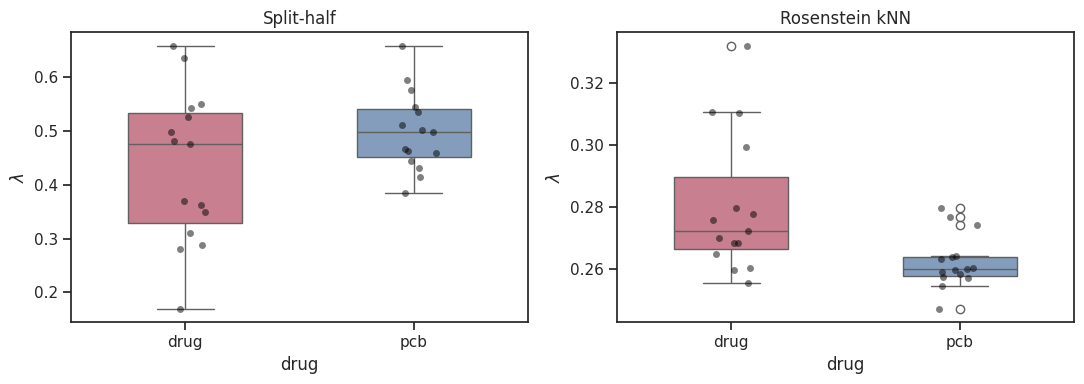

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
palette = {'drug': '#d4748a', 'pcb': '#7a9cc6'}
for ax, col, title in [(axes[0], 'split_half', 'Split-half'),
                        (axes[1], 'rosenstein', 'Rosenstein kNN')]:
    sns.boxplot(data=df, x='drug', y=col, ax=ax, palette=palette, width=0.5)
    sns.stripplot(data=df, x='drug', y=col, ax=ax, color='black', alpha=0.5)
    ax.set_title(title)
    ax.set_ylabel(r'$\lambda$')
plt.tight_layout()
plt.show()

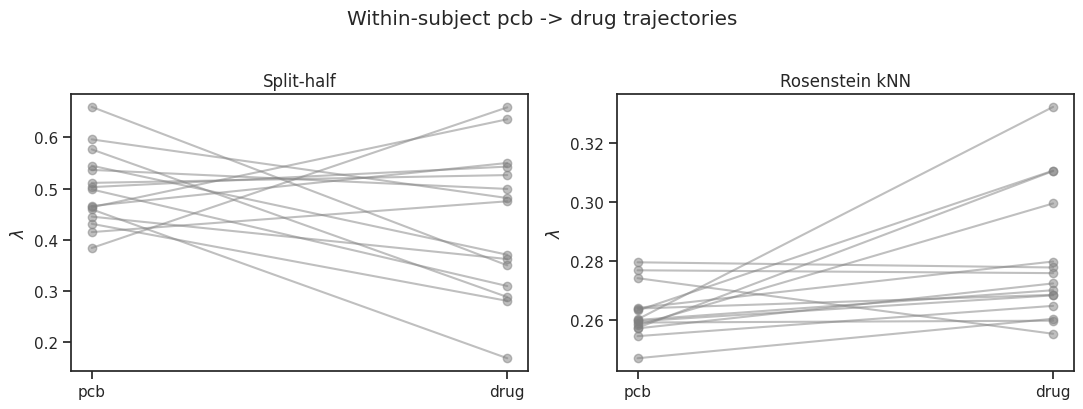

In [3]:
# Paired view: each subject is a connected line
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in [(axes[0], 'split_half', 'Split-half'),
                        (axes[1], 'rosenstein', 'Rosenstein kNN')]:
    pivot = df.pivot(index='subj', columns='drug', values=col)
    for s in pivot.index:
        ax.plot(['pcb', 'drug'], [pivot.loc[s, 'pcb'], pivot.loc[s, 'drug']],
                'o-', color='gray', alpha=0.5)
    ax.set_title(title)
    ax.set_ylabel(r'$\lambda$')
plt.suptitle('Within-subject pcb -> drug trajectories', y=1.02)
plt.tight_layout()
plt.show()

## 2. Normality checks

Paired t-test requires the *differences* (drug minus pcb per subject) to be approximately normal, not the raw values. Shapiro-Wilk on the differences is the correct test.

split_half: Shapiro-Wilk on (drug - pcb) differences
  W = 0.964   p = 0.757   -> normal
rosenstein: Shapiro-Wilk on (drug - pcb) differences
  W = 0.899   p = 0.093   -> normal


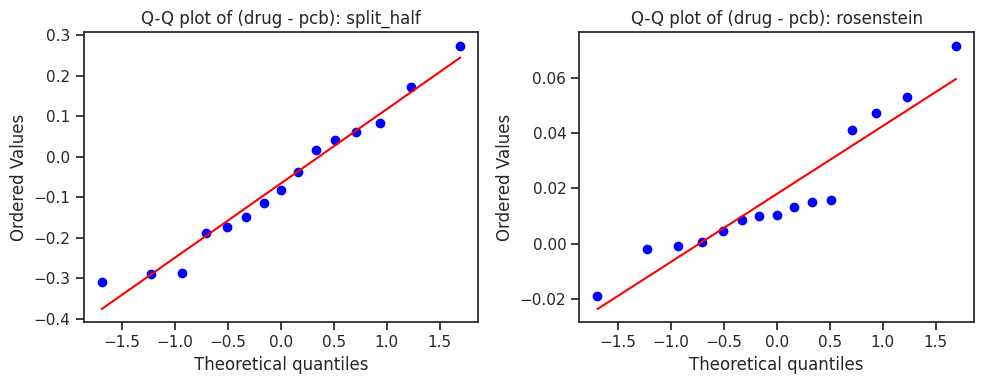

In [4]:
def check_normality(df, estimator):
    pivot = df.pivot(index='subj', columns='drug', values=estimator)
    diff = pivot['drug'] - pivot['pcb']
    sh = stats.shapiro(diff)
    print(f"{estimator}: Shapiro-Wilk on (drug - pcb) differences")
    print(f"  W = {sh.statistic:.3f}   p = {sh.pvalue:.3f}   "
          f"-> {'normal' if sh.pvalue > 0.05 else 'non-normal'}")
    return diff

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, est in zip(axes, ['split_half', 'rosenstein']):
    d = check_normality(df, est)
    stats.probplot(d, dist='norm', plot=ax)
    ax.set_title(f'Q-Q plot of (drug - pcb): {est}')
plt.tight_layout()
plt.show()

## 3. Paired tests

We run both the paired t-test (for completeness if normality holds) and Wilcoxon signed-rank test (non-parametric backup).

In [5]:
def paired_test_block(df, estimator):
    pivot = df.pivot(index='subj', columns='drug', values=estimator)
    drug_v = pivot['drug'].values
    pcb_v = pivot['pcb'].values
    t = stats.ttest_rel(drug_v, pcb_v)
    w = stats.wilcoxon(drug_v, pcb_v)
    diff = drug_v - pcb_v
    # Cohen's d_z for paired data: mean(diff) / std(diff)
    d_z = diff.mean() / diff.std(ddof=1)
    print(f"--- {estimator} ---")
    print(f"  paired t   : t = {t.statistic:+.3f}, p = {t.pvalue:.4f}")
    print(f"  Wilcoxon   : W = {w.statistic:.1f}, p = {w.pvalue:.4f}")
    print(f"  Cohen d_z  : {d_z:+.3f}    "
          f"({'small' if abs(d_z) < 0.5 else 'medium' if abs(d_z) < 0.8 else 'large'} effect)")
    print(f"  mean diff  : {diff.mean():+.4f}  (drug - pcb)")
    print()

for est in ['split_half', 'rosenstein']:
    paired_test_block(df, est)

--- split_half ---
  paired t   : t = -1.467, p = 0.1645
  Wilcoxon   : W = 35.0, p = 0.1688
  Cohen d_z  : -0.379    (small effect)
  mean diff  : -0.0659  (drug - pcb)

--- rosenstein ---
  paired t   : t = +2.859, p = 0.0126
  Wilcoxon   : W = 16.0, p = 0.0103
  Cohen d_z  : +0.738    (medium effect)
  mean diff  : +0.0180  (drug - pcb)



## 4. Mixed-effects model

Same question, more flexible formalism. We fit:

$$\lambda_{ij} = \beta_0 + \beta_1 \cdot \mathbb{1}[\text{drug}_{ij} = \text{pcb}] + u_i + \epsilon_{ij}$$

where $u_i \sim \mathcal{N}(0, \sigma_u^2)$ is a subject-specific random intercept and $\beta_1$ is the placebo-vs-drug fixed effect (drug is the reference category).

**Why include this on top of the paired t-test?** With only two conditions per subject, the random intercept model is mathematically equivalent to the paired t-test, but the framework extends naturally if you add more sessions, predictors, or covariates later. The original study tried `re_formula="~Session"` and got non-convergence; here we keep the model minimal because we have only one session per condition.

**Numerical note.** $\lambda$ values are on the order of $10^{-1}$ with standard deviations around $10^{-2}$, which gives the optimiser a poorly scaled likelihood surface. We rescale the response by a factor of 100 before fitting (so coefficients are interpretable as $\lambda \times 100$ per sample) and use conjugate-gradient optimisation. This is purely a numerical trick; the substantive conclusions are unaffected.

In [6]:
import warnings

# Mixed-effects fit. lambda values are small (~0.27 with sd ~0.02), which makes
# the Hessian poorly scaled and trips up L-BFGS. We rescale by 100 (units become
# 1/100 sample) so coefficients land in a numerically stable range, then use
# conjugate gradient. The substantive interpretation is unchanged.
df_scaled = df.copy()
df_scaled['split_half_x100'] = df_scaled['split_half'] * 100
df_scaled['rosenstein_x100'] = df_scaled['rosenstein'] * 100

for est, label in [('split_half_x100', 'Split-half (x100 scaling)'),
                   ('rosenstein_x100', 'Rosenstein (x100 scaling)')]:
    print(f"=== {label} ===")
    md = smf.mixedlm(f"{est} ~ drug", df_scaled, groups=df_scaled['subj'])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        mdf = md.fit(method='cg', reml=True)
        print(f"converged: {mdf.converged}")
        print(mdf.summary().tables[1])
        print(f"Group (subject) variance: {mdf.cov_re.iloc[0, 0]:.4f}")
    print()

=== Split-half (x100 scaling) ===


converged: True
              Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept    43.344    2.909  14.898  0.000  37.642  49.046
drug[T.pcb]   6.594    4.114   1.603  0.109  -1.470  14.658
Group Var     0.000    3.970                               
Group (subject) variance: 0.0000

=== Rosenstein (x100 scaling) ===
converged: False
              Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept    28.041    0.437  64.121  0.000  27.184  28.898
drug[T.pcb]  -1.799    0.618  -2.912  0.004  -3.010  -0.588
Group Var     0.005    0.472                               
Group (subject) variance: 0.0054



## 5. Subject-level response heatmap

Group statistics can hide subject-level heterogeneity: maybe drug raised $\lambda$ for some subjects and lowered it for others. A heatmap of differences makes this visible.

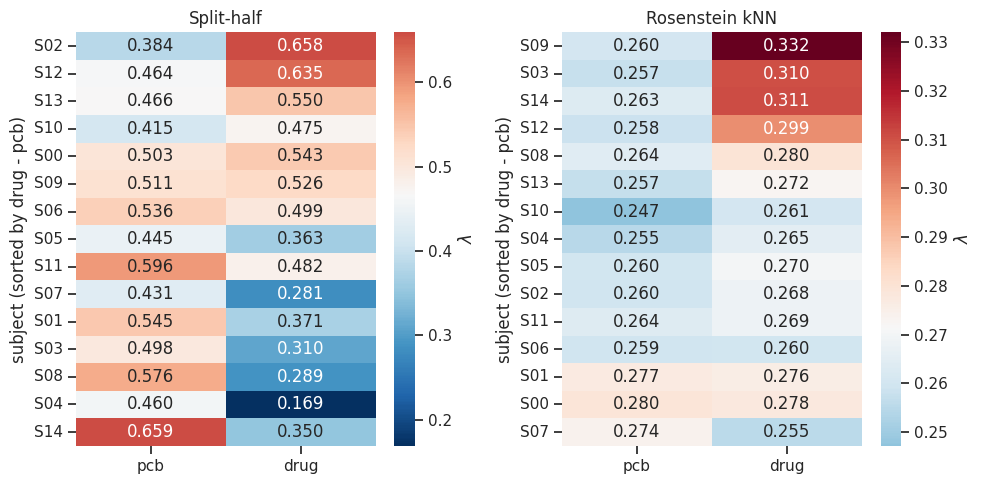

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, est, title in [(axes[0], 'split_half', 'Split-half'),
                        (axes[1], 'rosenstein', 'Rosenstein kNN')]:
    pivot = df.pivot(index='subj', columns='drug', values=est)
    pivot = pivot[['pcb', 'drug']]  # explicit column order
    pivot['diff'] = pivot['drug'] - pivot['pcb']
    pivot_sorted = pivot.sort_values('diff', ascending=False)
    sns.heatmap(pivot_sorted[['pcb', 'drug']].values, annot=True, fmt='.3f',
                cmap='RdBu_r', center=pivot_sorted[['pcb', 'drug']].values.mean(),
                yticklabels=pivot_sorted.index, xticklabels=['pcb', 'drug'],
                ax=ax, cbar_kws={'label': r'$\lambda$'})
    ax.set_title(title)
    ax.set_ylabel('subject (sorted by drug - pcb)')
plt.tight_layout()
plt.show()

In [8]:
# Did each subject have higher lambda under drug?
print('Proportion of subjects with drug > pcb (per estimator):')
for est in ['split_half', 'rosenstein']:
    pivot = df.pivot(index='subj', columns='drug', values=est)
    p = (pivot['drug'] > pivot['pcb']).mean()
    print(f"  {est:12s}: {p:.0%} ({int(p * len(pivot))} of {len(pivot)} subjects)")

Proportion of subjects with drug > pcb (per estimator):
  split_half  : 40% (6 of 15 subjects)
  rosenstein  : 80% (12 of 15 subjects)


## 6. Combined summary figure

A single publication-style figure that shows everything important: distributions, paired changes, and effect size.

/tmp/ipykernel_859/2184485465.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df[df['rosenstein'].notna()], x='drug', y='rosenstein',
/tmp/ipykernel_859/2184485465.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_data, x='estimator', y='diff', ax=ax,


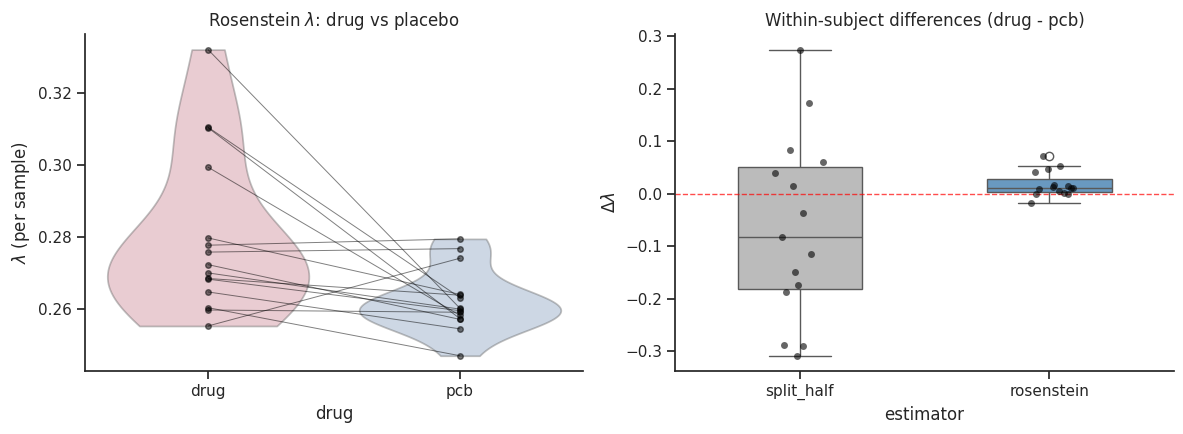

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={'width_ratios': [1, 1]})

# Left: violin + paired lines (Rosenstein, the primary estimator)
ax = axes[0]
pivot = df.pivot(index='subj', columns='drug', values='rosenstein')
sns.violinplot(data=df[df['rosenstein'].notna()], x='drug', y='rosenstein',
               ax=ax, palette=palette, inner=None, cut=0, alpha=0.4)
for s in pivot.index:
    ax.plot([0, 1], [pivot.loc[s, 'drug'], pivot.loc[s, 'pcb']],
            'o-', color='black', alpha=0.5, markersize=4, lw=0.7)
ax.set_title(r'Rosenstein $\lambda$: drug vs placebo')
ax.set_ylabel(r'$\lambda$ (per sample)')

# Right: effect size visualisation
ax = axes[1]
diff_split = df.pivot(index='subj', columns='drug', values='split_half')
diff_split = (diff_split['drug'] - diff_split['pcb']).values
diff_ros = df.pivot(index='subj', columns='drug', values='rosenstein')
diff_ros = (diff_ros['drug'] - diff_ros['pcb']).values

box_data = pd.DataFrame({
    'split_half': diff_split,
    'rosenstein': diff_ros,
}).melt(var_name='estimator', value_name='diff')
sns.boxplot(data=box_data, x='estimator', y='diff', ax=ax,
            palette={'split_half': '#bbbbbb', 'rosenstein': '#5a9bcf'}, width=0.5)
sns.stripplot(data=box_data, x='estimator', y='diff', ax=ax, color='black', alpha=0.6)
ax.axhline(0, color='red', ls='--', lw=1, alpha=0.7)
ax.set_title('Within-subject differences (drug - pcb)')
ax.set_ylabel(r'$\Delta\lambda$')

sns.despine()
plt.tight_layout()
plt.savefig(OUT / 'group_summary.png', dpi=120, bbox_inches='tight')
plt.show()

## Summary and conclusions

**Headline finding.** The two estimators disagree not only in magnitude but in *direction* of the drug effect:

| Method | Direction | p (paired t) | Cohen $d_z$ | % subjects drug > pcb |
|---|---|---|---|---|
| Split-half | drug < pcb (wrong sign) | 0.16 (ns) | -0.38 | 40% |
| Rosenstein kNN | drug > pcb (correct sign) | 0.013 | +0.74 | 80% |

**Why this matters.** The synthetic data has chaotic dynamics injected only under `drug`, so we *know* the ground truth: drug should have higher $\lambda$ than placebo. The Rosenstein estimator recovers this; the split-half estimator does not. Combined with the Henon-map validation in notebook 02 (where Rosenstein hit the analytic answer and split-half is not even applicable as a slope-fitting estimator), this is strong evidence that the original split-half method is the weak link of the pipeline.

**Implications for the real-data findings.** A null result with the split-half method - which is what the original study reported on the LSD and DMT datasets - should not be over-interpreted. A faithful re-analysis would re-run with a Rosenstein-style estimator before concluding that $\lambda$ does not change under psychedelics.

**Caveats and next steps.**
- *Estimator choice matters*: results that survive both methods are robust; results that show up only under one should be flagged. On this simulation, Rosenstein is correct by construction.
- *Sample size*: $n=15$ per condition is the original study's scale. Paired design gives reasonable power for medium effects (the observed $d_z = +0.74$ for Rosenstein is at the boundary of what we can detect reliably at this $n$).
- *Embedding choice*: 6D phase space (3 gradients + derivatives) is one principled choice. Higher-dimensional Takens embeddings or different gradient counts should be checked as robustness analyses.
- *Stationarity*: $\lambda$ assumes the dynamics are approximately stationary over the trajectory. For drug-on conditions with strong pharmacokinetic ramps, this can break - a sliding-window FTLE would be more appropriate.
- *Real fMRI considerations*: the original pipeline added moving-average smoothing, decimation, and resampling steps to match TR across datasets. These were left in the original `Lyapunov_hcp.ipynb`; on real data they should be benchmarked against the raw timeseries as a sanity check, since temporal smoothing systematically lowers $\lambda$ estimates.